# Priority Access After Congestion

## FCFS vs second-price auction · Week 5 downstream application

> **Boundary — This notebook is a downstream scarcity-allocation application after congestion is identified. It is not the core disclosure mechanism.**

### Mechanism map

**Congested corridor**

↓

**Residual demand exceeds capacity**

↓

**One priority slot ($K=1$)**

↓

**FCFS or second-price allocation**

↓

**Compare allocated value, efficiency, and revenue**

↓

**Bounded-rationality stress test**

This notebook uses normalized private values and a deliberately narrow independent-private-values (IPV) benchmark. It is not an empirical model of mission urgency or willingness to pay.

## Week 5 mechanism checklist

| Required element | Operational definition |
|---|---|
| **Scarce resource** | One priority-access slot for a congested low-altitude corridor during a fixed short window; $K=1$. |
| **Participants** | Eligible non-emergency commercial drone operators. |
| **Values/signals** | Private normalized value $v_i$: avoided delay cost plus service value of earlier passage. |
| **Information** | Each operator knows its own value; the benchmark assumes independent private values. |
| **Bids/reports** | FCFS receives valid requests; the auction receives sealed bids $b_i$. |
| **Allocation rule** | FCFS selects the earliest eligible request; second price selects the highest eligible bid. |
| **Payment rule** | FCFS payment is zero; the auction winner pays the second-highest eligible bid. |
| **Stopping rule** | FCFS stops when capacity is filled; auction bidding closes at a fixed deadline. |
| **Rational benchmark** | Truthful bidding is weakly dominant in the standard second-price IPV benchmark. |
| **Boundary** | Emergency/public-safety flights are outside the commercial payment mechanism. |

In [1]:
from pathlib import Path
import subprocess
import sys

REPO_URL = 'https://github.com/dku-comsci-econ206-Autumn2026/PS2-FP10-ShareOrHide-Yiqiao.git'
REPO_NAME = 'PS2-FP10-ShareOrHide-Yiqiao'
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    ROOT = Path('/content') / REPO_NAME
    if not ROOT.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", REPO_URL, str(ROOT)],
            check=True,
        )
else:
    ROOT = Path.cwd().resolve()
    if ROOT.name == "notebooks":
        ROOT = ROOT.parent

if not (ROOT / "src").is_dir():
    raise RuntimeError(
        f"Expected a repository containing src/ at {ROOT}. "
        "Run locally from the repository root or notebooks directory."
    )
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import csv
import importlib.metadata as metadata
import platform

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display

from src.priority_slot_allocation import (
    allocate_fcfs,
    second_price_auction,
    simulate_bid_noise_stress,
    simulate_truthful_comparison,
)

TABLE_DIR = ROOT / "outputs" / "tables"
FIGURE_DIR = ROOT / "outputs" / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SEED = 206
STRESS_SEED = 1206
ROUNDS = 10_000
N_BIDDERS = 4
VALUE_LOW, VALUE_HIGH = 0.0, 10.0
NOISE_SIGMAS = (0.0, 0.1, 0.25, 0.5, 1.0)
COLORS = ["#2563EB", "#0F766E"]

def write_csv(path, rows):
    rows = list(rows)
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)

def display_table(rows, columns):
    header = "| " + " | ".join(label for _, label in columns) + " |"
    divider = "|" + "|".join("---" for _ in columns) + "|"
    body = [
        "| " + " | ".join(str(row[key]) for key, _ in columns) + " |"
        for row in rows
    ]
    display(Markdown("\n".join([header, divider, *body])))

def save_figure(fig, stem):
    png_path = FIGURE_DIR / f"{stem}.png"
    for extension in ("png", "svg"):
        fig.savefig(FIGURE_DIR / f"{stem}.{extension}", dpi=180, bbox_inches="tight")
    display(Image(filename=str(png_path)))
    plt.close(fig)

print(f"Repository ready: {REPO_NAME}")
print(f"Tables: {TABLE_DIR.relative_to(ROOT)}")
print(f"Figures: {FIGURE_DIR.relative_to(ROOT)}")

Repository ready: PS2-FP10-ShareOrHide-Yiqiao
Tables: outputs/tables
Figures: outputs/figures


## Illustrative four-operator benchmark

Normalized private values are A: 8, B: 5, C: 3, D: 2. They are illustrative values, not empirical estimates or dollar amounts.

For FCFS, arrival order is B, C, A, D. With $K=1$, B wins. For the sealed-bid auction, bids are truthful in the IPV benchmark. The payment is a transfer to the traffic authority: it reduces the winner's utility and raises auctioneer revenue by the same amount. In this simplest transfer-neutral welfare convention, money does not disappear, so social welfare equals allocated value rather than allocated value minus revenue.

In [2]:
benchmark_values = {"A": 8, "B": 5, "C": 3, "D": 2}
arrival_order = ["B", "C", "A", "D"]

fcfs_benchmark = allocate_fcfs(arrival_order, benchmark_values, capacity=1)
auction_benchmark = second_price_auction(benchmark_values, values=benchmark_values)

benchmark_rows = [
    {
        "mechanism": "FCFS",
        "winner": fcfs_benchmark.winners[0],
        "allocated_value": fcfs_benchmark.allocated_value,
        "maximum_feasible_value": fcfs_benchmark.max_feasible_value,
        "payment": fcfs_benchmark.payment,
        "winner_utility": fcfs_benchmark.winner_utility,
        "auctioneer_revenue": 0.0,
        "allocative_efficiency": fcfs_benchmark.allocative_efficiency,
        "social_welfare_transfer_neutral": fcfs_benchmark.social_welfare,
    },
    {
        "mechanism": "Second-price auction (truthful IPV benchmark)",
        "winner": auction_benchmark.winner,
        "allocated_value": auction_benchmark.allocated_value,
        "maximum_feasible_value": auction_benchmark.highest_feasible_value,
        "payment": auction_benchmark.payment,
        "winner_utility": auction_benchmark.winner_utility,
        "auctioneer_revenue": auction_benchmark.auctioneer_revenue,
        "allocative_efficiency": auction_benchmark.allocative_efficiency,
        "social_welfare_transfer_neutral": auction_benchmark.social_welfare,
    },
]
benchmark_path = TABLE_DIR / "auction_benchmark_example.csv"
write_csv(benchmark_path, benchmark_rows)
for row in benchmark_rows:
    print(row)
print(f"Saved {benchmark_path.relative_to(ROOT)}")

{'mechanism': 'FCFS', 'winner': 'B', 'allocated_value': 5.0, 'maximum_feasible_value': 8.0, 'payment': 0.0, 'winner_utility': 5.0, 'auctioneer_revenue': 0.0, 'allocative_efficiency': 0.625, 'social_welfare_transfer_neutral': 5.0}
{'mechanism': 'Second-price auction (truthful IPV benchmark)', 'winner': 'A', 'allocated_value': 8.0, 'maximum_feasible_value': 8.0, 'payment': 5.0, 'winner_utility': 3.0, 'auctioneer_revenue': 5.0, 'allocative_efficiency': 1.0, 'social_welfare_transfer_neutral': 8.0}
Saved outputs/tables/auction_benchmark_example.csv


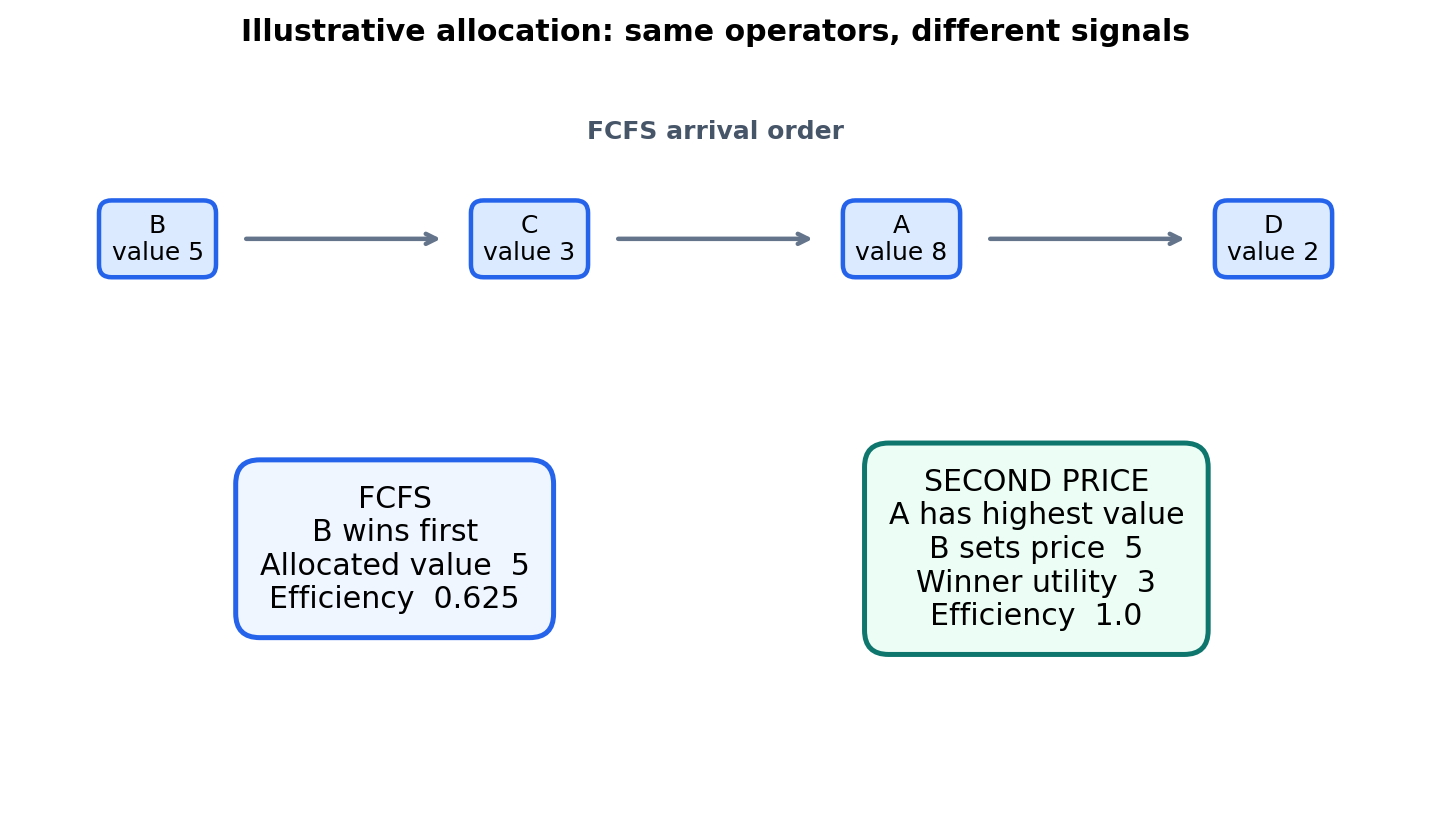

In [3]:
fcfs_row, auction_row = benchmark_rows
fig, ax = plt.subplots(figsize=(10.0, 5.2))
ax.axis("off")
ax.set_title("Illustrative allocation: same operators, different signals", fontweight="bold", pad=16)

arrival_x = np.linspace(0.10, 0.90, len(arrival_order))
for index, (x_pos, operator) in enumerate(zip(arrival_x, arrival_order)):
    ax.text(
        x_pos,
        0.78,
        f"{operator}\nvalue {benchmark_values[operator]:g}",
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.5", fc="#DBEAFE", ec="#2563EB", lw=1.8),
    )
    if index < len(arrival_order) - 1:
        ax.annotate("", xy=(arrival_x[index + 1] - 0.06, 0.78), xytext=(x_pos + 0.06, 0.78), arrowprops=dict(arrowstyle="->", color="#64748B", lw=1.8))
ax.text(0.5, 0.92, "FCFS arrival order", ha="center", color="#475569", fontweight="bold")

fcfs_text = (
    "FCFS\n"
    f"{fcfs_row['winner']} wins first\n"
    f"Allocated value  {fcfs_row['allocated_value']:.0f}\n"
    f"Efficiency  {fcfs_row['allocative_efficiency']:.3f}"
)
auction_text = (
    "SECOND PRICE\n"
    f"{auction_row['winner']} has highest value\n"
    f"{fcfs_row['winner']} sets price  {auction_row['payment']:.0f}\n"
    f"Winner utility  {auction_row['winner_utility']:.0f}\n"
    f"Efficiency  {auction_row['allocative_efficiency']:.1f}"
)
ax.text(0.27, 0.35, fcfs_text, ha="center", va="center", fontsize=12, bbox=dict(boxstyle="round,pad=0.8", fc="#EFF6FF", ec="#2563EB", lw=2))
ax.text(0.73, 0.35, auction_text, ha="center", va="center", fontsize=12, bbox=dict(boxstyle="round,pad=0.8", fc="#ECFDF5", ec="#0F766E", lw=2))
save_figure(fig, "auction_illustrative_mechanism_map")

### Mechanism comparison

| Feature | FCFS | Second price |
|---|---|---|
| Signal used | Arrival order | Bid/value |
| Winner | Earliest eligible request | Highest eligible bid |
| Payment | 0 | Second-highest bid |
| Benchmark strategy | Valid request | Truthful bidding is weakly dominant under IPV |
| Strength | Operational simplicity | Allocative efficiency under the benchmark |
| Limitation | Ignores value | Ability-to-pay concerns and IPV assumptions |

> **Interpretation —** Second price is more efficient in this benchmark, but that narrow ranking does not make it universally superior.

## Monte Carlo design and efficiency definition

We simulate 10,000 independent rounds with four eligible commercial operators. Values are i.i.d. $\mathrm{Uniform}[0,10]$ normalized private values. In each round, FCFS arrival order is an independent uniformly random permutation, implemented by sorting i.i.d. continuous random arrival keys. The seed is fixed.

For $K=1$, normalized allocative efficiency is

$$\frac{\text{value of allocated winner}}{\text{highest feasible value}}.$$

Truthful second-price bidding under IPV therefore allocates to the highest-value bidder and has efficiency 1 (up to zero-probability numerical edge cases). Revenue is recorded separately and is **not** interpreted as welfare.

In [4]:
simulation = simulate_truthful_comparison(
    rounds=ROUNDS,
    n_bidders=N_BIDDERS,
    seed=SEED,
    value_low=VALUE_LOW,
    value_high=VALUE_HIGH,
)

summary_rows = [
    {
        "mechanism": "FCFS",
        "rounds": ROUNDS,
        "seed": SEED,
        "mean_allocated_value": float(np.mean(simulation["fcfs_allocated_value"])),
        "mean_payment_revenue": float(np.mean(simulation["fcfs_payment"])),
        "payment_revenue_sd": float(np.std(simulation["fcfs_payment"], ddof=1)),
        "payment_revenue_median": float(np.median(simulation["fcfs_payment"])),
        "payment_revenue_q95": float(np.quantile(simulation["fcfs_payment"], 0.95)),
        "mean_winner_utility": float(np.mean(simulation["fcfs_allocated_value"])),
        "mean_allocative_efficiency": float(np.mean(simulation["fcfs_efficiency"])),
        "mean_social_welfare_transfer_neutral": float(np.mean(simulation["fcfs_social_welfare"])),
    },
    {
        "mechanism": "Second-price auction (truthful IPV benchmark)",
        "rounds": ROUNDS,
        "seed": SEED,
        "mean_allocated_value": float(np.mean(simulation["second_price_highest_value"])),
        "mean_payment_revenue": float(np.mean(simulation["second_price_revenue"])),
        "payment_revenue_sd": float(np.std(simulation["second_price_revenue"], ddof=1)),
        "payment_revenue_median": float(np.median(simulation["second_price_revenue"])),
        "payment_revenue_q95": float(np.quantile(simulation["second_price_revenue"], 0.95)),
        "mean_winner_utility": float(np.mean(simulation["second_price_winner_utility"])),
        "mean_allocative_efficiency": float(np.mean(simulation["second_price_efficiency"])),
        "mean_social_welfare_transfer_neutral": float(np.mean(simulation["second_price_social_welfare"])),
    },
]
summary_path = TABLE_DIR / "auction_simulation_summary.csv"
write_csv(summary_path, summary_rows)
for row in summary_rows:
    print(row)
print(f"Saved {summary_path.relative_to(ROOT)}")

{'mechanism': 'FCFS', 'rounds': 10000, 'seed': 206, 'mean_allocated_value': 4.968558238253884, 'mean_payment_revenue': 0.0, 'payment_revenue_sd': 0.0, 'payment_revenue_median': 0.0, 'payment_revenue_q95': 0.0, 'mean_winner_utility': 4.968558238253884, 'mean_allocative_efficiency': 0.6223078074284918, 'mean_social_welfare_transfer_neutral': 4.968558238253884}
{'mechanism': 'Second-price auction (truthful IPV benchmark)', 'rounds': 10000, 'seed': 206, 'mean_allocated_value': 7.999828606802081, 'mean_payment_revenue': 5.992069244988238, 'payment_revenue_sd': 1.975861796607607, 'payment_revenue_median': 6.1005045066701005, 'payment_revenue_q95': 9.020349527956833, 'mean_winner_utility': 2.007759361813843, 'mean_allocative_efficiency': 1.0, 'mean_social_welfare_transfer_neutral': 7.999828606802081}
Saved outputs/tables/auction_simulation_summary.csv


In [5]:
display(Markdown("### Monte Carlo result"))
design_rows = [{
    "Rounds": f"{ROUNDS:,}",
    "Bidders": N_BIDDERS,
    "Values": f"iid Uniform[{VALUE_LOW:g},{VALUE_HIGH:g}]",
    "Seed": SEED,
}]
display_table(design_rows, [("Rounds", "Rounds"), ("Bidders", "Bidders"), ("Values", "Values"), ("Seed", "Seed")])

simulation_display = [
    {
        "Mechanism": row["mechanism"].replace(" (truthful IPV benchmark)", ""),
        "Mean efficiency": f"{row['mean_allocative_efficiency']:.10f}",
        "Transfer-neutral welfare": f"{row['mean_social_welfare_transfer_neutral']:.6f}",
        "Mean revenue": f"{row['mean_payment_revenue']:.6f}",
        "Median revenue": f"{row['payment_revenue_median']:.6f}",
        "95th percentile revenue": f"{row['payment_revenue_q95']:.6f}",
    }
    for row in summary_rows
]
display_table(
    simulation_display,
    [
        ("Mechanism", "Mechanism"),
        ("Mean efficiency", "Mean efficiency"),
        ("Transfer-neutral welfare", "Transfer-neutral welfare"),
        ("Mean revenue", "Mean revenue"),
        ("Median revenue", "Median revenue"),
        ("95th percentile revenue", "95th percentile revenue"),
    ],
)
display(Markdown(
    "> **Welfare convention —** Payments are transfers: they reduce winner utility and raise auctioneer revenue by the same amount. Transfer-neutral social welfare therefore equals allocated value."
))

### Monte Carlo result

| Rounds | Bidders | Values | Seed |
|---|---|---|---|
| 10,000 | 4 | iid Uniform[0,10] | 206 |

| Mechanism | Mean efficiency | Transfer-neutral welfare | Mean revenue | Median revenue | 95th percentile revenue |
|---|---|---|---|---|---|
| FCFS | 0.6223078074 | 4.968558 | 0.000000 | 0.000000 | 0.000000 |
| Second-price auction | 1.0000000000 | 7.999829 | 5.992069 | 6.100505 | 9.020350 |

> **Welfare convention —** Payments are transfers: they reduce winner utility and raise auctioneer revenue by the same amount. Transfer-neutral social welfare therefore equals allocated value.

## Behavioral / bounded-rationality stress test

The truthful benchmark is $b_i=v_i$. To study misunderstanding of second-price incentives, we add controlled multiplicative bid noise:

$$b_i=\max(0,v_i\epsilon_i), \qquad \epsilon_i\sim\operatorname{LogNormal}(-\sigma^2/2,\sigma).$$

Thus $E[\epsilon_i]=1$. The $\sigma=0$ row is truthful; positive $\sigma$ rows are a **behavioral / bounded-rationality stress test**, not rational equilibrium behavior. Values remain i.i.d. Uniform[0,10], and all results use a fixed seed.

In [6]:
stress_rows = simulate_bid_noise_stress(
    rounds=ROUNDS,
    n_bidders=N_BIDDERS,
    seed=STRESS_SEED,
    noise_sigmas=NOISE_SIGMAS,
    value_low=VALUE_LOW,
    value_high=VALUE_HIGH,
)
for row in stress_rows:
    row.update({"rounds": ROUNDS, "seed": STRESS_SEED, "noise_distribution": "LogNormal(-sigma^2/2, sigma)"})

stress_path = TABLE_DIR / "auction_behavioral_stress_test.csv"
write_csv(stress_path, stress_rows)
for row in stress_rows:
    print(row)
print(f"Saved {stress_path.relative_to(ROOT)}")

{'behavior': 'truthful benchmark', 'noise_sigma': 0.0, 'mean_allocative_efficiency': 1.0, 'std_allocative_efficiency': 0.0, 'efficiency_q05': 1.0, 'efficiency_median': 1.0, 'efficiency_q95': 1.0, 'misallocation_rate': 0.0, 'rounds': 10000, 'seed': 1206, 'noise_distribution': 'LogNormal(-sigma^2/2, sigma)'}
{'behavior': 'behavioral / bounded-rationality stress test', 'noise_sigma': 0.1, 'mean_allocative_efficiency': 0.9895140391989831, 'std_allocative_efficiency': 0.03437936207316676, 'efficiency_q05': 0.9148987401511732, 'efficiency_median': 1.0, 'efficiency_q95': 1.0, 'misallocation_rate': 0.1393, 'rounds': 10000, 'seed': 1206, 'noise_distribution': 'LogNormal(-sigma^2/2, sigma)'}
{'behavior': 'behavioral / bounded-rationality stress test', 'noise_sigma': 0.25, 'mean_allocative_efficiency': 0.9565637867571597, 'std_allocative_efficiency': 0.09379605222066288, 'efficiency_q05': 0.7351277092327766, 'efficiency_median': 1.0, 'efficiency_q95': 1.0, 'misallocation_rate': 0.2783, 'rounds': 

In [7]:
stress_display = [
    {
        "Noise sigma": f"{row['noise_sigma']:g}",
        "Mean allocative efficiency": f"{row['mean_allocative_efficiency']:.6f}",
    }
    for row in stress_rows
]
display(Markdown("### Non-equilibrium stress-test results"))
display_table(stress_display, [("Noise sigma", "Bid-noise sigma"), ("Mean allocative efficiency", "Mean allocative efficiency")])
display(Markdown(
    "> **Interpretation —** Positive noise levels are controlled deviations from truthful bidding, not predicted equilibrium behavior."
))

### Non-equilibrium stress-test results

| Bid-noise sigma | Mean allocative efficiency |
|---|---|
| 0 | 1.000000 |
| 0.1 | 0.989514 |
| 0.25 | 0.956564 |
| 0.5 | 0.904572 |
| 1 | 0.826281 |

> **Interpretation —** Positive noise levels are controlled deviations from truthful bidding, not predicted equilibrium behavior.

## Visual comparison

The following figures use the live simulation arrays created above. Efficiency and revenue are reported separately because revenue is a transfer under the benchmark welfare convention.

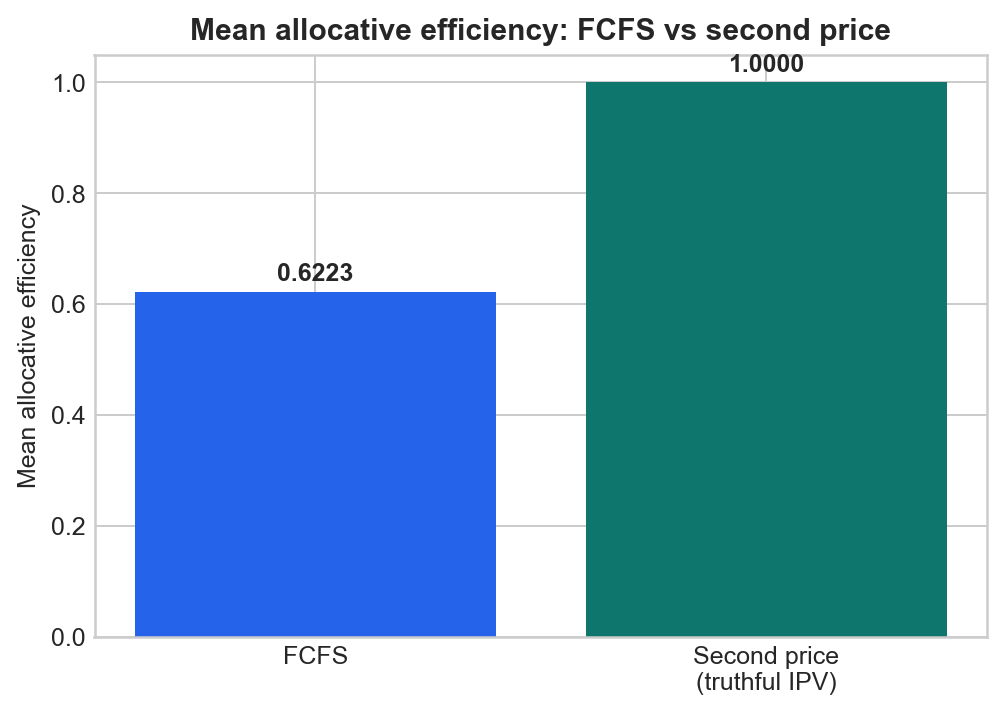

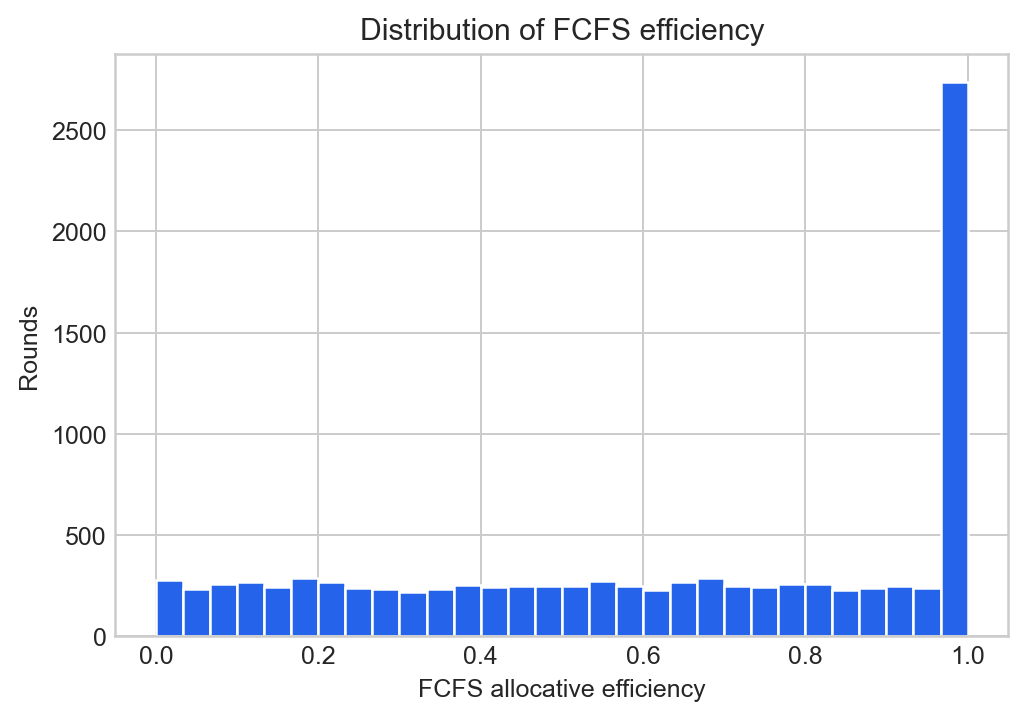

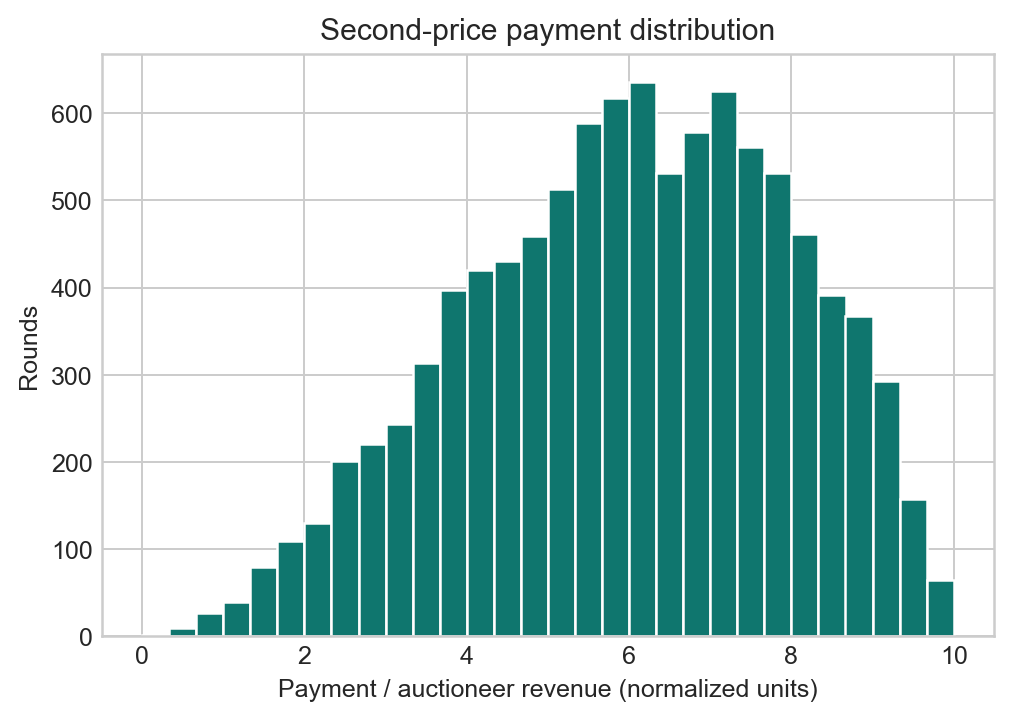

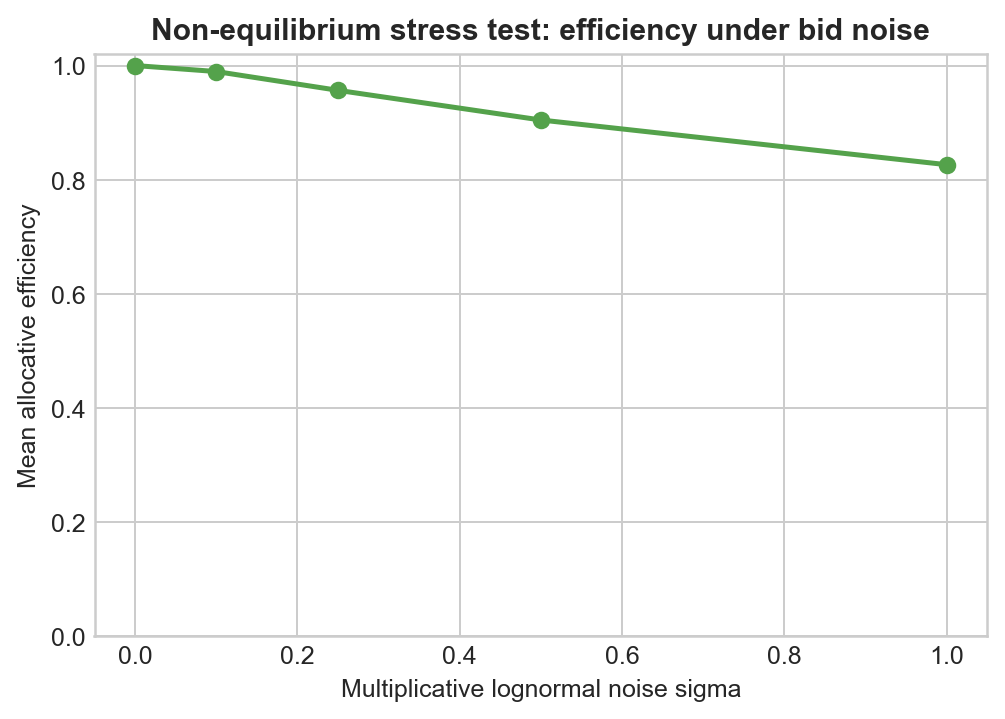

Saved four figures in PNG and SVG formats:
outputs/figures/auction_average_efficiency.png
outputs/figures/auction_average_efficiency.svg
outputs/figures/auction_fcfs_efficiency_distribution.png
outputs/figures/auction_fcfs_efficiency_distribution.svg
outputs/figures/auction_illustrative_mechanism_map.png
outputs/figures/auction_illustrative_mechanism_map.svg
outputs/figures/auction_second_price_revenue_distribution.png
outputs/figures/auction_second_price_revenue_distribution.svg
outputs/figures/auction_truthful_vs_noisy_efficiency.png
outputs/figures/auction_truthful_vs_noisy_efficiency.svg


In [8]:
plt.style.use("seaborn-v0_8-whitegrid")

# 1. Mean allocative efficiency
fig, ax = plt.subplots(figsize=(6.4, 4.2))
means = [summary_rows[0]["mean_allocative_efficiency"], summary_rows[1]["mean_allocative_efficiency"]]
ax.bar(["FCFS", "Second price\n(truthful IPV)"], means, color=COLORS)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Mean allocative efficiency")
ax.set_title("Mean allocative efficiency: FCFS vs second price", fontweight="bold")
for index, value in enumerate(means):
    ax.text(index, value + 0.02, f"{value:.4f}", ha="center", fontweight="bold")
save_figure(fig, "auction_average_efficiency")

# 2. Distribution of FCFS efficiency
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.hist(simulation["fcfs_efficiency"], bins=np.linspace(0, 1, 31), color=COLORS[0], edgecolor="white")
ax.set_xlabel("FCFS allocative efficiency")
ax.set_ylabel("Rounds")
ax.set_title("Distribution of FCFS efficiency")
save_figure(fig, "auction_fcfs_efficiency_distribution")

# 3. Second-price revenue/payment distribution
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.hist(simulation["second_price_revenue"], bins=np.linspace(0, 10, 31), color=COLORS[1], edgecolor="white")
ax.set_xlabel("Payment / auctioneer revenue (normalized units)")
ax.set_ylabel("Rounds")
ax.set_title("Second-price payment distribution")
save_figure(fig, "auction_second_price_revenue_distribution")

# 4. Truthful versus noisy bidding
fig, ax = plt.subplots(figsize=(6.4, 4.2))
sigmas = [row["noise_sigma"] for row in stress_rows]
efficiencies = [row["mean_allocative_efficiency"] for row in stress_rows]
ax.plot(sigmas, efficiencies, color="#54A24B", marker="o", linewidth=2)
ax.set_ylim(0, 1.02)
ax.set_xlabel("Multiplicative lognormal noise sigma")
ax.set_ylabel("Mean allocative efficiency")
ax.set_title("Non-equilibrium stress test: efficiency under bid noise", fontweight="bold")
save_figure(fig, "auction_truthful_vs_noisy_efficiency")

print("Saved four figures in PNG and SVG formats:")
for path in sorted(FIGURE_DIR.glob("auction_*")):
    print(path.relative_to(ROOT))

## Interpretation and policy limitations

Second price can improve allocative efficiency under the IPV assumptions used here, but the benchmark does not resolve:

- ability-to-pay and unequal-access concerns;
- whether bids measure social urgency;
- common or interdependent mission values;
- mission criticality and noncommercial public value;
- the legitimacy of monetizing access.

> **Safety boundary — Emergency and public-safety flights remain outside the commercial auction.**

### Connection to the disclosure project

Better disclosure can improve congestion prediction and scheduling, yet residual scarcity may remain. The allocation layer begins only after that scarcity is identified. Disclosure, congestion, and allocation are not collapsed into one mathematical model.

## Reproducibility record

In [9]:
package_names = ["numpy", "matplotlib", "nbformat", "nbclient", "ipykernel"]
metadata_rows = [
    {"item": "python_version", "value": platform.python_version()},
    *[{"item": f"package_{name}", "value": metadata.version(name)} for name in package_names],
    {"item": "truthful_seed", "value": SEED},
    {"item": "stress_seed", "value": STRESS_SEED},
    {"item": "simulation_rounds", "value": ROUNDS},
    {"item": "eligible_bidders_per_round", "value": N_BIDDERS},
    {"item": "capacity_K", "value": 1},
    {"item": "value_distribution", "value": "iid Uniform[0,10] normalized units"},
    {"item": "fcfs_arrival_order", "value": "independent uniformly random permutation"},
    {"item": "stress_noise", "value": "mean-one multiplicative lognormal"},
    {"item": "table_output_path", "value": str(TABLE_DIR.relative_to(ROOT))},
    {"item": "figure_output_path", "value": str(FIGURE_DIR.relative_to(ROOT))},
]
metadata_path = TABLE_DIR / "auction_run_metadata.csv"
write_csv(metadata_path, metadata_rows)
for row in metadata_rows:
    print(f"{row['item']}: {row['value']}")
print(f"Saved {metadata_path.relative_to(ROOT)}")

python_version: 3.13.7
package_numpy: 2.3.5
package_matplotlib: 3.10.8
package_nbformat: 5.10.4
package_nbclient: 0.10.2
package_ipykernel: 7.1.0
truthful_seed: 206
stress_seed: 1206
simulation_rounds: 10000
eligible_bidders_per_round: 4
capacity_K: 1
value_distribution: iid Uniform[0,10] normalized units
fcfs_arrival_order: independent uniformly random permutation
stress_noise: mean-one multiplicative lognormal
table_output_path: outputs/tables
figure_output_path: outputs/figures
Saved outputs/tables/auction_run_metadata.csv


In [10]:
display(Markdown("## Final result card"))
display_table(
    [
        {
            "Comparison": "Illustrative example",
            "FCFS": f"{100 * fcfs_benchmark.allocative_efficiency:.1f}%",
            "Second price": f"{100 * auction_benchmark.allocative_efficiency:.0f}%",
        },
        {
            "Comparison": "Monte Carlo mean",
            "FCFS": f"{100 * summary_rows[0]['mean_allocative_efficiency']:.1f}%",
            "Second price": f"{100 * summary_rows[1]['mean_allocative_efficiency']:.0f}%",
        },
    ],
    [("Comparison", "Comparison"), ("FCFS", "FCFS"), ("Second price", "Second price")],
)
display(Markdown(
    "**Noise stress:** second-price allocative efficiency falls as bids become noisier.  \n"
    "**Boundary:** downstream commercial allocation only; not the core disclosure mechanism."
))

## Final result card

| Comparison | FCFS | Second price |
|---|---|---|
| Illustrative example | 62.5% | 100% |
| Monte Carlo mean | 62.2% | 100% |

**Noise stress:** second-price allocative efficiency falls as bids become noisier.  
**Boundary:** downstream commercial allocation only; not the core disclosure mechanism.

### Continue exploring

- [GitHub repository](https://github.com/dku-comsci-econ206-Autumn2026/PS2-FP10-ShareOrHide-Yiqiao)
- [Run this notebook in Colab](https://colab.research.google.com/github/dku-comsci-econ206-Autumn2026/PS2-FP10-ShareOrHide-Yiqiao/blob/main/notebooks/02_priority_slot_allocation.ipynb)
- [Behavioral Decision Lab](https://huggingface.co/spaces/dku-comsci-econ206-2026/ps2-share-or-hide-drone-disclosure)